### Estimating Polynya Area and HSSW Production Rate from Surface Heat Fluxes 

In [1]:
import xarray as xr 
import numpy as np 
import matplotlib.pyplot as plt 
import glob

### Load in SIC data 

In [2]:
files = glob.glob(
    r"C:\Users\mblan\Documents\TNB_Research\data\SIC_Ross\**\*.nc",
    recursive=True
)

In [3]:
files

['C:\\Users\\mblan\\Documents\\TNB_Research\\data\\SIC_Ross\\SIC_Ross_2016_2019.nc',
 'C:\\Users\\mblan\\Documents\\TNB_Research\\data\\SIC_Ross\\SIC_TNB_2016_2019.nc',
 'C:\\Users\\mblan\\Documents\\TNB_Research\\data\\SIC_Ross\\2012\\asi-AMSR2-s3125-20120801-v5.4.nc',
 'C:\\Users\\mblan\\Documents\\TNB_Research\\data\\SIC_Ross\\2012\\asi-AMSR2-s3125-20120802-v5.4.nc',
 'C:\\Users\\mblan\\Documents\\TNB_Research\\data\\SIC_Ross\\2012\\asi-AMSR2-s3125-20120803-v5.4.nc',
 'C:\\Users\\mblan\\Documents\\TNB_Research\\data\\SIC_Ross\\2012\\asi-AMSR2-s3125-20120804-v5.4.nc',
 'C:\\Users\\mblan\\Documents\\TNB_Research\\data\\SIC_Ross\\2012\\asi-AMSR2-s3125-20120805-v5.4.nc',
 'C:\\Users\\mblan\\Documents\\TNB_Research\\data\\SIC_Ross\\2012\\asi-AMSR2-s3125-20120806-v5.4.nc',
 'C:\\Users\\mblan\\Documents\\TNB_Research\\data\\SIC_Ross\\2012\\asi-AMSR2-s3125-20120807-v5.4.nc',
 'C:\\Users\\mblan\\Documents\\TNB_Research\\data\\SIC_Ross\\2012\\asi-AMSR2-s3125-20120808-v5.4.nc',
 'C:\\Users\\mb

In [ ]:
import glob
import xarray as xr

files = glob.glob(
    r"C:\Users\mblan\Documents\TNB_Research\data\SIC_Ross\**\*.nc",
    recursive=True
)

sic = xr.open_mfdataset(
    files,
    combine="by_coords"
)

print(sic)

C:\Users\mblan\AppData\Local\Temp\ipykernel_12620\2473576933.py:9: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'x' ('x',) The recommendation is to set join explicitly for this case.
  sic = xr.open_mfdataset(

KeyboardInterrupt



In [4]:
one = xr.open_dataset(files[1])


In [5]:
print(one)

<xarray.Dataset> Size: 218MB
Dimensions:              (time: 1461, x: 102, y: 122)
Coordinates:
  * time                 (time) datetime64[ns] 12kB 2016-01-01 ... 2019-12-31
  * x                    (x) float64 816B 3.172e+05 3.203e+05 ... 6.328e+05
    lon                  (y, x) float64 100kB ...
    lat                  (y, x) float64 100kB ...
  * y                    (y) float64 976B -1.811e+06 -1.808e+06 ... -1.433e+06
Data variables:
    polar_stereographic  (time, x, y) |S8 145MB ...
    sic                  (time, y, x) float32 73MB ...
Attributes:
    author:       University of Bremen, Gunnar Spreen [gunnar.spreen@uni-brem...
    Conventions:  CF-1.5
    GMT_version:  6.3.0 [64-bit]
    history:      Wed May 29 16:59:39 2024: GDAL CreateCopy( /mnt/web//data/a...
    info:         AMSR2 sea ice concentration based on the ASI algorithm (Spr...
    title:        Produced by grdmath
    GDAL:         GDAL 3.4.1, released 2021/12/27


In [ ]:
import xarray as xr
import pandas as pd
import glob
import re
import numpy as np

In [ ]:
def get_time_from_filename(fname):
    match = re.search(r'(\d{8})', fname)
    if match is None:
        raise ValueError(f"No date found in filename: {fname}")
    return pd.to_datetime(match.group(1), format='%Y%m%d')

In [ ]:
files = glob.glob(
    r"C:\Users\mblan\Documents\TNB_Research\data\SIC_Ross\**\*.nc",
    recursive=True
)

datasets = []

for f in files:
    ds = xr.open_dataset(f)

    # rename variable if needed
    ds = ds.rename({"z": "sic"})  # sea ice concentration

    # add time dimension
    time = get_time_from_filename(f)
    ds = ds.expand_dims({"time": [time]})

    datasets.append(ds)

ValueError: cannot rename 'z' because it is not a variable or dimension in this dataset

In [ ]:
len(datasets)

1461

In [ ]:
datasets[9]

<xarray.Dataset> Size: 27MB
Dimensions:              (time: 1, y: 2656, x: 2528)
Coordinates:
  * time                 (time) datetime64[ns] 8B 2016-01-10
  * y                    (y) float64 21kB -3.948e+06 -3.945e+06 ... 4.348e+06
  * x                    (x) float64 20kB -3.948e+06 -3.945e+06 ... 3.948e+06
Data variables:
    polar_stereographic  (time) |S1 1B b''
    sic                  (time, y, x) float32 27MB 0.0 0.0 0.0 ... 0.0 0.0 0.0
Attributes:
    author:       University of Bremen, Gunnar Spreen [gunnar.spreen@uni-brem...
    Conventions:  CF-1.5
    GMT_version:  6.3.0 [64-bit]
    history:      Wed May 29 16:59:58 2024: GDAL CreateCopy( /mnt/web//data/a...
    info:         AMSR2 sea ice concentration based on the ASI algorithm (Spr...
    title:        Produced by grdmath
    GDAL:         GDAL 3.4.1, released 2021/12/27

In [ ]:
ds_all = xr.concat(datasets, dim="time")

In [ ]:
ds_all

<xarray.Dataset> Size: 39GB
Dimensions:              (time: 1461, y: 2656, x: 2528)
Coordinates:
  * time                 (time) datetime64[ns] 12kB 2016-01-01 ... 2019-12-31
  * y                    (y) float64 21kB -3.948e+06 -3.945e+06 ... 4.348e+06
  * x                    (x) float64 20kB -3.948e+06 -3.945e+06 ... 3.948e+06
Data variables:
    polar_stereographic  (time) |S1 1kB b'' b'' b'' b'' b'' ... b'' b'' b'' b''
    sic                  (time, y, x) float32 39GB 0.0 0.0 0.0 ... 0.0 0.0 0.0
Attributes:
    author:       University of Bremen, Gunnar Spreen [gunnar.spreen@uni-brem...
    Conventions:  CF-1.5
    GMT_version:  6.3.0 [64-bit]
    history:      Wed May 29 16:59:39 2024: GDAL CreateCopy( /mnt/web//data/a...
    info:         AMSR2 sea ice concentration based on the ASI algorithm (Spr...
    title:        Produced by grdmath
    GDAL:         GDAL 3.4.1, released 2021/12/27

In [ ]:
# rough Ross Sea bounds (you may tweak)
x_min, x_max = -2.2e6, 1.5e6
y_min, y_max = -2.2e6, -0.2e6

In [ ]:
ds_ross = ds_all.where(
    (ds_all.x >= x_min) &
    (ds_all.x <= x_max) &
    (ds_all.y >= y_min) &
    (ds_all.y <= y_max),
    drop=True
)

In [ ]:
ds_ross

<xarray.Dataset> Size: 13GB
Dimensions:              (time: 1461, x: 1184, y: 640)
Coordinates:
  * time                 (time) datetime64[ns] 12kB 2016-01-01 ... 2019-12-31
  * x                    (x) float64 9kB -2.198e+06 -2.195e+06 ... 1.498e+06
  * y                    (y) float64 5kB -2.198e+06 -2.195e+06 ... -2.016e+05
Data variables:
    polar_stereographic  (time, x, y) object 9GB b'' b'' b'' b'' ... b'' b'' b''
    sic                  (time, y, x) float32 4GB 0.0 0.0 0.0 ... nan nan nan
Attributes:
    author:       University of Bremen, Gunnar Spreen [gunnar.spreen@uni-brem...
    Conventions:  CF-1.5
    GMT_version:  6.3.0 [64-bit]
    history:      Wed May 29 16:59:39 2024: GDAL CreateCopy( /mnt/web//data/a...
    info:         AMSR2 sea ice concentration based on the ASI algorithm (Spr...
    title:        Produced by grdmath
    GDAL:         GDAL 3.4.1, released 2021/12/27

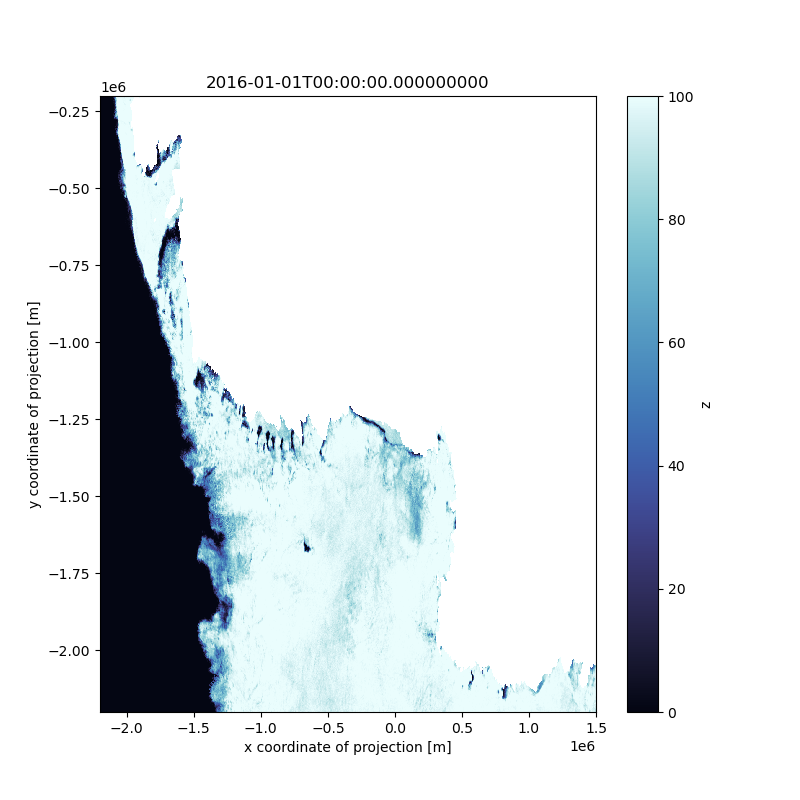

In [ ]:
ds_ross.sic.isel(time=500).plot(
    cmap=cmocean.cm.ice,
    vmin=0,
    vmax=100,
    figsize=(8,8)
)

plt.title(str(ds_ross.time.isel(time=0).values))
plt.show()

In [ ]:
x_min = 0.2e6
x_max = 0.9e6

y_min = -2.5e6
y_max = -1.6e6

In [ ]:
ds_tnb = ds_ross.where(
    (ds_ross.x >= x_min) &
    (ds_ross.x <= x_max) &
    (ds_ross.y >= y_min) &
    (ds_ross.y <= y_max),
    drop=True
)

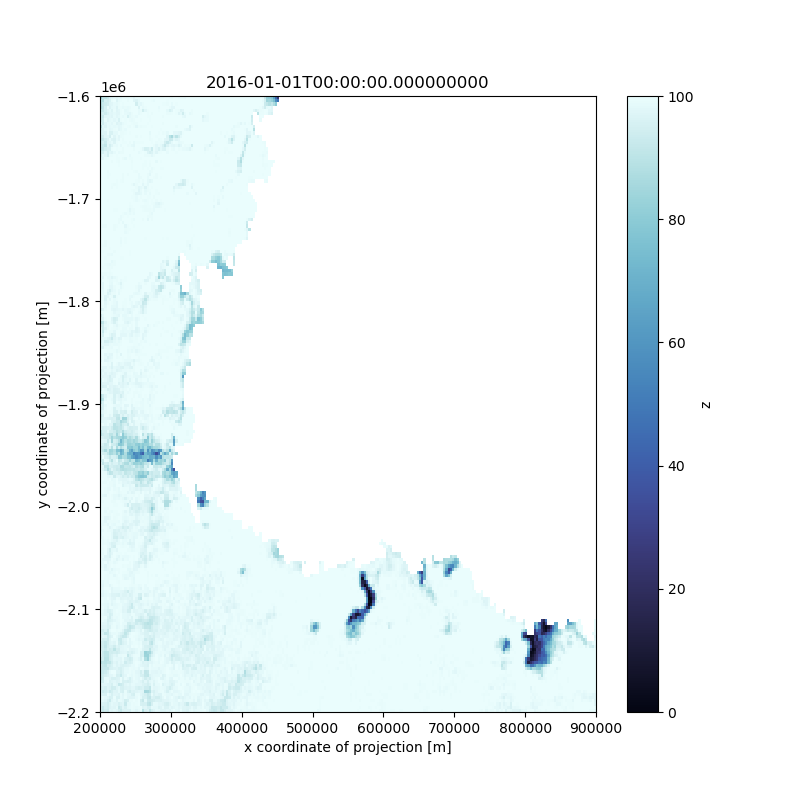

In [ ]:
ds_tnb.sic.isel(time=500).plot(
    cmap=cmocean.cm.ice,
    vmin=0,
    vmax=100,
    figsize=(8,8)
)

plt.title(str(ds_tnb.time.isel(time=0).values))
plt.show()

In [2]:
# # load in SIC data 
# # open TNB dataset - MAC
# tnb = xr.open_dataset('/Users/mackenzie/Documents/Research/PhD/TNB_Research/data/SIC_TNB_2016_2019.nc')

# open TNB dataset - DELL 
tnb = xr.open_dataset('/Users/mblan/Documents/TNB_Research/data/SIC_Ross/SIC_TNB_2016_2019.nc')

In [3]:
tnb

<xarray.Dataset> Size: 218MB
Dimensions:              (time: 1461, x: 102, y: 122)
Coordinates:
  * time                 (time) datetime64[ns] 12kB 2016-01-01 ... 2019-12-31
  * x                    (x) float64 816B 3.172e+05 3.203e+05 ... 6.328e+05
    lon                  (y, x) float64 100kB ...
    lat                  (y, x) float64 100kB ...
  * y                    (y) float64 976B -1.811e+06 -1.808e+06 ... -1.433e+06
Data variables:
    polar_stereographic  (time, x, y) |S8 145MB ...
    sic                  (time, y, x) float32 73MB ...
Attributes:
    author:       University of Bremen, Gunnar Spreen [gunnar.spreen@uni-brem...
    Conventions:  CF-1.5
    GMT_version:  6.3.0 [64-bit]
    history:      Wed May 29 16:59:39 2024: GDAL CreateCopy( /mnt/web//data/a...
    info:         AMSR2 sea ice concentration based on the ASI algorithm (Spr...
    title:        Produced by grdmath
    GDAL:         GDAL 3.4.1, released 2021/12/27

(-75.4, -74.5)

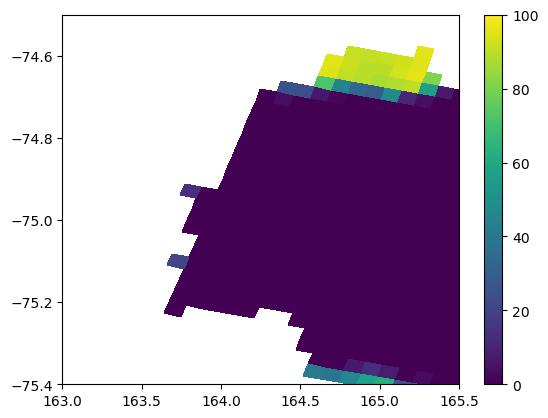

In [4]:
fig = plt.figure()
plt.pcolormesh(tnb.lon,tnb.lat,tnb.sic.isel(time=0))
plt.colorbar()
plt.xlim(163,165.5)
plt.ylim(-75.4,-74.5)

In [5]:
subset = tnb.where(
    (tnb.lon >= 163) &
    (tnb.lon <= 165) &
    (tnb.lat >= -75.2) &
    (tnb.lat <= -74.7),
    drop=True
)

In [6]:
subset

<xarray.Dataset> Size: 9MB
Dimensions:              (time: 1461, x: 22, y: 22)
Coordinates:
  * time                 (time) datetime64[ns] 12kB 2016-01-01 ... 2019-12-31
  * x                    (x) float64 176B 4.203e+05 4.234e+05 ... 4.859e+05
    lon                  (y, x) float64 4kB 165.3 165.2 165.1 ... 162.6 162.5
    lat                  (y, x) float64 4kB -74.75 -74.74 ... -75.16 -75.15
  * y                    (y) float64 176B -1.608e+06 -1.605e+06 ... -1.542e+06
Data variables:
    polar_stereographic  (time, x, y) object 6MB nan nan nan nan ... nan nan nan
    sic                  (time, y, x) float32 3MB nan nan nan ... nan nan nan
Attributes:
    author:       University of Bremen, Gunnar Spreen [gunnar.spreen@uni-brem...
    Conventions:  CF-1.5
    GMT_version:  6.3.0 [64-bit]
    history:      Wed May 29 16:59:39 2024: GDAL CreateCopy( /mnt/web//data/a...
    info:         AMSR2 sea ice concentration based on the ASI algorithm (Spr...
    title:        Produced by grdmath
    GDAL:         GDAL 3.4.1, released 2021/12/27

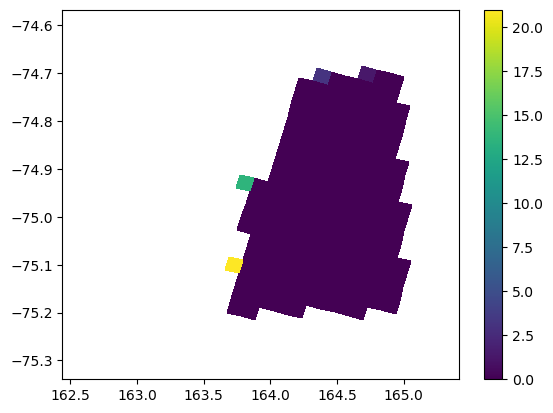

In [7]:
fig = plt.figure()
plt.pcolormesh(subset.lon,subset.lat,subset.sic.isel(time=0))
plt.colorbar()
# plt.xlim(163,165.5)
# plt.ylim(-75.4,-74.5)

In [8]:
# estimate polynya area 
threshold = 30 #percent 

In [9]:
day = subset.isel(time=0)

In [10]:
sic_day = day.where(day.sic > 30, drop=True).sic

In [11]:
np.nancumsum(sic_day)

array([], dtype=float32)

In [12]:
# Counts all valid numbers (Returns: 4)
pixel_count = np.sum(~np.isnan(sic_day))

In [13]:
polynya_area = pixel_count * 3.125**2

In [14]:
area = []
for day in range(len(subset.time)):
    d = subset.isel(time=day)
    sic_day = d.where(d.sic > 30, drop=True).sic
    pixel_count = np.sum(~np.isnan(sic_day))
    polynya_area = pixel_count * 3.125**2
    area.append(polynya_area)

In [15]:
len(area)

1461

In [16]:
polynya_area = xr.concat(area,dim='time')

Text(0, 0.5, 'Polynya Area [km^2]')

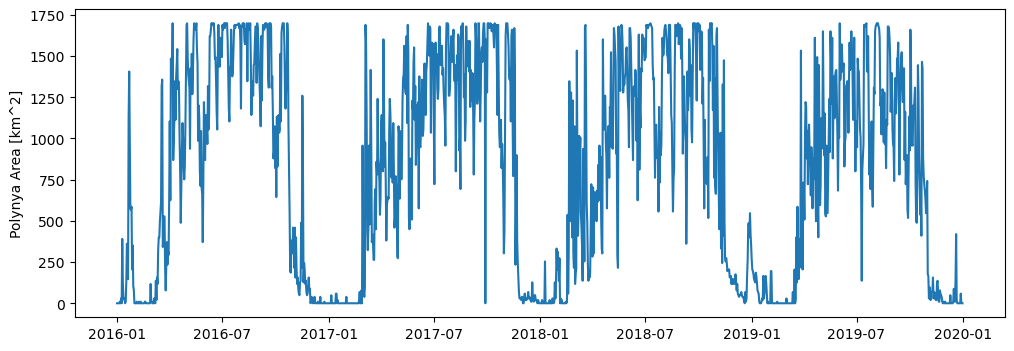

In [17]:
fig = plt.figure(figsize=(12,4))
plt.plot(polynya_area.time,polynya_area)
plt.ylabel('Polynya Area [km^2]')


In [18]:
area_2018 = polynya_area.sel(time=slice('2018-01','2018-12'))

In [19]:
area_2018

<xarray.DataArray 'sic' (time: 365)> Size: 3kB
array([   0.      ,    0.      ,    0.      ,   19.53125 ,    0.      ,
          0.      ,    0.      ,    0.      ,  253.90625 ,    0.      ,
          0.      ,    0.      ,    0.      ,    0.      ,    0.      ,
          0.      ,   19.53125 ,    0.      ,    0.      ,    0.      ,
          0.      ,   29.296875,    9.765625,    0.      ,    9.765625,
        126.953125,   29.296875,  126.953125,  332.03125 ,  205.078125,
        312.5     ,  253.90625 ,  136.71875 ,  273.4375  ,    0.      ,
         29.296875,    0.      ,   19.53125 ,    0.      ,    0.      ,
          0.      ,    0.      ,    0.      ,    0.      ,    9.765625,
          0.      ,    9.765625,  537.109375,   58.59375 ,  312.5     ,
       1347.65625 , 1044.921875,  498.046875, 1279.296875,  703.125   ,
        400.390625, 1230.46875 ,  312.5     ,  214.84375 , 1074.21875 ,
        117.1875  ,  185.546875,  205.078125, 1533.203125,  810.546875,
        410.15625 ,  566.40625 , 1015.625   ,  898.4375  , 1005.859375,
        546.875   ,  458.984375,  341.796875,  136.71875 ,  937.5     ,
        527.34375 ,  253.90625 , 1679.6875  , 1689.453125, 1240.234375,
        605.46875 ,  488.28125 ,  244.140625,  136.71875 ,  185.546875,
        156.25    ,  185.546875,  439.453125,  722.65625 ,  341.796875,
        283.203125,  703.125   ,  302.734375,  644.53125 ,  673.828125,
        673.828125,  664.0625  ,  498.046875,  683.59375 ,  615.234375,
...
       1669.921875, 1699.21875 , 1699.21875 , 1640.625   , 1484.375   ,
       1230.46875 , 1699.21875 , 1689.453125, 1699.21875 , 1650.390625,
       1689.453125, 1416.015625, 1425.78125 , 1650.390625, 1630.859375,
       1210.9375  , 1367.1875  ,  986.328125,  576.171875, 1113.28125 ,
        732.421875,  839.84375 ,  820.3125  ,  722.65625 ,  888.671875,
        517.578125, 1660.15625 , 1347.65625 , 1699.21875 , 1699.21875 ,
       1689.453125, 1699.21875 , 1542.96875 , 1171.875   , 1562.5     ,
        761.71875 , 1367.1875  ,  712.890625,  664.0625  , 1621.09375 ,
       1669.921875, 1250.      ,  937.5     ,  703.125   ,  449.21875 ,
        849.609375, 1035.15625 ,  332.03125 ,  507.8125  ,  244.140625,
       1328.125   ,  410.15625 , 1474.609375,  498.046875,  273.4375  ,
        253.90625 ,  273.4375  ,  244.140625,  195.3125  ,  205.078125,
        195.3125  ,  205.078125,  156.25    ,  156.25    ,  166.015625,
        117.1875  ,  146.484375,  117.1875  ,  146.484375,  126.953125,
        117.1875  ,  136.71875 ,  175.78125 ,  126.953125,   78.125   ,
        117.1875  ,   58.59375 ,   48.828125,   39.0625  ,   48.828125,
         48.828125,   58.59375 ,   68.359375,   48.828125,   39.0625  ,
         39.0625  ,   29.296875,    9.765625,    0.      ,   68.359375,
          9.765625,   29.296875,  166.015625,  263.671875,  478.515625,
        488.28125 ,  400.390625,  546.875   ,  419.921875,  351.5625  ])
Coordinates:
  * time     (time) datetime64[ns] 3kB 2018-01-01 2018-01-02 ... 2018-12-31
Attributes:
    long_name:     z
    actual_range:  [  0 100]
    grid_mapping:  polar_stereographic

Text(0, 0.5, 'Polynya Area [km^2]')

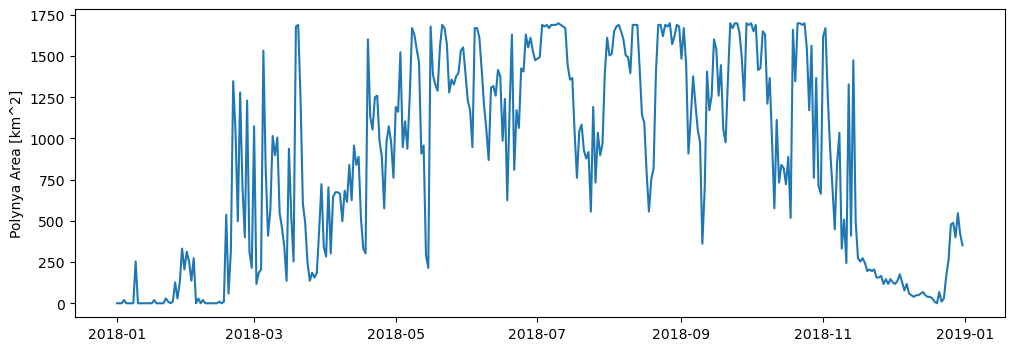

In [20]:
fig = plt.figure(figsize=(12,4))
plt.plot(area_2018.time,area_2018)
plt.ylabel('Polynya Area [km^2]')

In [21]:
polynya_area

<xarray.DataArray 'sic' (time: 1461)> Size: 12kB
array([0., 0., 0., ..., 0., 0., 0.], shape=(1461,))
Coordinates:
  * time     (time) datetime64[ns] 12kB 2016-01-01 2016-01-02 ... 2019-12-31
Attributes:
    long_name:     z
    actual_range:  [  0 100]
    grid_mapping:  polar_stereographic

In [23]:
area_2018.to_netcdf("polynya_area_2018.nc")